In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [4]:
!pip install xlsxwriter

In [4]:
## Загрузка таблицы №1 - данные о клиентах
df_cust = pd.read_csv('customers_20260606.csv')
df_cust.head(3)

,customer_id,first_name,last_name,email,phone,registration_date,city,district,is_active,acquisition_channel
0,1,Татьяна,Смирнова,user1@freshbox.local,79339670711,2024-02-27,Санкт-Петербург,Приморский,True,referral
1,2,Светлана,Иванова,user2@freshbox.local,79131994523,2024-10-06,Санкт-Петербург,Центральный,True,organic
2,3,Александр,Смирнова,user3@freshbox.local,79868820204,2024-09-15,Санкт-Петербург,Невский,True,referral


In [7]:
## Информация о типах данных в столбцах и количестве строк в таблице
df_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2500 non-null   int64 
 1   first_name           2500 non-null   object
 2   last_name            2500 non-null   object
 3   email                2500 non-null   object
 4   phone                2500 non-null   int64 
 5   registration_date    2500 non-null   object
 6   city                 2500 non-null   object
 7   district             2500 non-null   object
 8   is_active            2500 non-null   bool  
 9   acquisition_channel  2500 non-null   object
dtypes: bool(1), int64(2), object(7)
memory usage: 178.4+ KB


In [11]:
df_summary = pd.DataFrame({'cust_reg' : [df_cust['customer_id'].nunique()], \
                           'cust_act' : [df_cust[df_cust['is_active'] == True]['customer_id'].nunique()]})
print(df_summary)

   cust_reg  cust_act
0      2500      2133


In [19]:
print (f"Общее количество зарегистрированных клиентов {df_cust['customer_id'].nunique()}")

Общее количество зарегистрированных клиентов 2500


In [21]:
print (f"Общее количество активных клиентов {df_cust[df_cust['is_active'] == True]['customer_id'].nunique()}")

Общее количество активных клиентов 2133


In [23]:
## В списке - id неактивных клиентов
list_na = df_cust[df_cust['is_active'] == False]['customer_id'].to_list()

In [25]:
## Все клиенты - из Санкт-Петербурга
df_cust['city'].value_counts()

city
Санкт-Петербург    2500
Name: count, dtype: int64

In [17]:
## Распределение клиентов по каналам привлечения
df_cust['acquisition_channel'].value_counts()

acquisition_channel
organic     1025
social       604
referral     493
paid         378
Name: count, dtype: int64

In [31]:
## Преобразование даты регистрации в формат даты и времени
df_cust['registration_date'] = pd.to_datetime(df_cust['registration_date'], errors = 'coerce')

In [33]:
## Добавление  таблицу колонки с годом-месяцем регистрации
df_cust['reg_y_m'] = df_cust['registration_date'].dt.to_period('M')
df_cust.head(3)

,customer_id,first_name,last_name,email,phone,registration_date,city,district,is_active,acquisition_channel,reg_y_m
0,1,Татьяна,Смирнова,user1@freshbox.local,79339670711,2024-02-27,Санкт-Петербург,Приморский,True,referral,2024-02
1,2,Светлана,Иванова,user2@freshbox.local,79131994523,2024-10-06,Санкт-Петербург,Центральный,True,organic,2024-10
2,3,Александр,Смирнова,user3@freshbox.local,79868820204,2024-09-15,Санкт-Петербург,Невский,True,referral,2024-09


In [35]:
## Группировка клиентов по месяцу регистрации (когортам)
df_coh = df_cust.groupby(['reg_y_m'])['customer_id'].count().reset_index()
df_coh

,reg_y_m,customer_id
0,2024-01,233
1,2024-02,248
2,2024-03,280
3,2024-04,223
4,2024-05,245
5,2024-06,256
6,2024-07,238
7,2024-08,283
8,2024-09,260
9,2024-10,234


In [37]:
## Создание сводной таблицы по распределении клиентов в каждой когорте по каналам привлечения
df_cust_pt = df_cust.pivot_table(index='reg_y_m',
                                 columns='acquisition_channel',
                                values='customer_id',
                                aggfunc='count').reset_index()
df_cust_pt['tot_cust'] = df_cust_pt['organic'] + df_cust_pt['paid'] + df_cust_pt['referral'] + df_cust_pt['social']
df_cust_pt

acquisition_channel,reg_y_m,organic,paid,referral,social,tot_cust
0,2024-01,83,38,44,68,233
1,2024-02,110,33,49,56,248
2,2024-03,110,52,55,63,280
3,2024-04,98,34,40,51,223
4,2024-05,108,26,53,58,245
5,2024-06,106,36,51,63,256
6,2024-07,91,38,45,64,238
7,2024-08,117,46,60,60,283
8,2024-09,107,43,50,60,260
9,2024-10,95,32,46,61,234


In [41]:
max_rd = df_cust['reg_y_m'].max()
df_cust_new = df_cust[(df_cust['reg_y_m'] <= max_rd) & (df_cust['reg_y_m'] > max_rd - 3) & df_cust['is_active'] == True]['customer_id'].count()
print (f'Доля новых пользователей (регистрация в последние 3 месяца) - {round(df_cust_new / df_cust[df_cust['is_active'] == True]['customer_id'].nunique() *100, 1)} %')

Доля новых пользователей (регистрация в последние 3 месяца) - 30.8 %


In [45]:
df_summary['share_new'] = round(df_cust_new / df_cust[df_cust['is_active'] == True]['customer_id'].nunique(), 1)
print(df_summary)

   cust_reg  cust_act  share_new
0      2500      2133        0.3


In [47]:
## Загрузка таблицы №2 - информация о составе заказов
df_oi = pd.read_csv('order_items_20260606.csv')
df_oi.head(3)

,item_id,order_id,product_id,quantity,price_at_purchase,discount_percent
0,1,1,30,0.41,145.27,5
1,2,1,12,0.53,86.70,0
2,3,1,92,1.08,322.88,5


In [49]:
## Информация о типе данных в столбцах и количестве строк в таблице
df_oi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82337 entries, 0 to 82336
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            82337 non-null  int64  
 1   order_id           82337 non-null  int64  
 2   product_id         82337 non-null  int64  
 3   quantity           82337 non-null  float64
 4   price_at_purchase  82337 non-null  float64
 5   discount_percent   82337 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 3.8 MB


In [51]:
## Расчет стоимости купленных товаров (с учетом скидки)
df_oi['total_sum'] = round((df_oi['quantity'] * df_oi['price_at_purchase'] * (100 - df_oi['discount_percent']) / 100), 2)
df_oi.head(3)

,item_id,order_id,product_id,quantity,price_at_purchase,discount_percent,total_sum
0,1,1,30,0.41,145.27,5,56.58
1,2,1,12,0.53,86.70,0,45.95
2,3,1,92,1.08,322.88,5,331.27


In [53]:
## Определение количества позиций и общей суммы каждого заказа
df_ord_info = df_oi.groupby('order_id').agg({'item_id' : 'count', 'total_sum' : 'sum'}).reset_index().rename(columns = {'item_id' : 'cnt_items'})
df_ord_info.head(3)

,order_id,cnt_items,total_sum
0,1,4,581.80
1,2,7,1491.83
2,3,5,705.85


In [55]:
df_ord_info['total_sum'].sum()
print (f"Общая сумма выручки за весь период {df_ord_info['total_sum'].sum()}")

Общая сумма выручки за весь период 20283734.23


In [57]:
print (f"Средняя сумма заказа {round(df_ord_info['total_sum'].sum() / df_ord_info['order_id'].count(), 2)}")

Средняя сумма заказа 1126.87


In [59]:
print (f"Общее количество заказов за весь период {df_ord_info['order_id'].count()}")

Общее количество заказов за весь период 18000


In [61]:
print (f'Среднее количество позиций в одном заказе {round(df_ord_info['cnt_items'].mean(), 1)}')

Среднее количество позиций в одном заказе 4.6


In [63]:
df_summary['tot_rev'] = df_ord_info['total_sum'].sum()
df_summary['avg_ord_sum'] = round(df_ord_info['total_sum'].sum() / df_ord_info['order_id'].count(), 2)
df_summary['cnt_ord'] = df_ord_info['order_id'].count()
df_summary['avg_items_per_ord'] = round(df_ord_info['cnt_items'].mean(), 1)
print (df_summary)

   cust_reg  cust_act  share_new      tot_rev  avg_ord_sum  cnt_ord  \
0      2500      2133        0.3  20283734.23      1126.87    18000   

   avg_items_per_ord  
0                4.6  


In [65]:
## Информация о свойствах числовых значений таблицы о заказах
df_ord_info.describe()

,order_id,cnt_items,total_sum
count,18000.000000,18000.000000,18000.000000
mean,9000.500000,4.574278,1126.874124
std,5196.296758,2.300410,751.513609
min,1.000000,1.000000,19.490000
25%,4500.750000,3.000000,546.327500
50%,9000.500000,4.000000,993.605000
75%,13500.250000,6.000000,1559.805000
max,18000.000000,18.000000,5503.250000


In [67]:
## Определим границы межквартильного размаха по суммам заказа
Q1 = np.percentile(df_ord_info['total_sum'], 25)
Q3 = np.percentile(df_ord_info['total_sum'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print (lower_bound, upper_bound)

-973.8887500000002 3080.0212500000002


In [77]:
## Выделение заказов с суммами, выходящими за пределы границ межквартильного размаха
large_orders = df_ord_info.loc[df_ord_info['total_sum'] > upper_bound].sort_values('total_sum', ascending = False)
large_orders.describe()

,order_id,cnt_items,total_sum
count,307.000000,307.000000,307.000000
mean,8710.019544,9.228013,3573.674137
std,5167.892839,2.145096,436.580760
min,30.000000,5.000000,3082.320000
25%,4216.000000,8.000000,3240.330000
50%,8757.000000,9.000000,3482.090000
75%,13151.500000,10.500000,3825.075000
max,17992.000000,18.000000,5503.250000


In [170]:
df_ord_mi = df_ord_info[(df_ord_info['cnt_items'] > 10)]
print (f'Количество заказов с количеством позиций более 10 - {df_ord_mi['order_id'].count()}')

Количество заказов с количеством позиций более 10 - 254


In [172]:
df_anomalis = pd.DataFrame({'cnt_large_ord' : [large_orders['order_id'].count()], \
                           'avg_items_l_ord' : [round(large_orders['cnt_items'].mean(),1)],\
                           'avg_sum_l_ord' : [round(large_orders['total_sum'].mean(),1)],\
                           'cnt_ord_11+items' : [df_ord_mi['order_id'].count()]})
print(df_anomalis)

   cnt_large_ord  avg_items_l_ord  avg_sum_l_ord  cnt_ord_11+items
0            307              9.2         3573.7               254


In [99]:
## Функция определения категорий заказов по их суммам
def tot_sum_group (tot_sum):
    if tot_sum < 1000:
        return '0-1000'
    elif (tot_sum >= 1000) and (tot_sum < 2000):
        return '1000-1999'
    elif (tot_sum >= 2000) and (tot_sum < 3000):
        return '2000-2999'
    elif (tot_sum >= 3000) and (tot_sum < 4000):
        return '3000-3999'
    elif (tot_sum >= 4000) and (tot_sum < 5000):
        return '4000-4999'
    else:
        return '5000+'

In [101]:
## Применение функции для определения категорий заказов
df_ord_info['sum_group'] = df_ord_info['total_sum'].apply(tot_sum_group)
df_ord_info.head()

,order_id,cnt_items,total_sum,sum_group
0,1,4,581.80,0-1000
1,2,7,1491.83,1000-1999
2,3,5,705.85,0-1000
3,4,2,101.09,0-1000
4,5,4,577.90,0-1000


In [103]:
## Группировка заказов по категориям
df_ts_group = df_ord_info.groupby('sum_group').agg({'order_id' : 'count', 'cnt_items' : 'mean', 'total_sum' : 'mean'}).reset_index()\
.rename(columns = {'order_id' : 'cnt_ord', 'cnt_items' : 'avg_items', 'total_sum' : 'avg_sum'}).sort_values('sum_group')
df_ts_group

,sum_group,cnt_ord,avg_items,avg_sum
0,0-1000,9065,3.194153,544.393268
1,1000-1999,6611,5.386023,1422.972199
2,2000-2999,1952,7.381660,2380.487049
3,3000-3999,329,8.778116,3361.184954
4,4000-4999,40,10.925000,4317.689750
5,5000+,3,13.666667,5430.630000


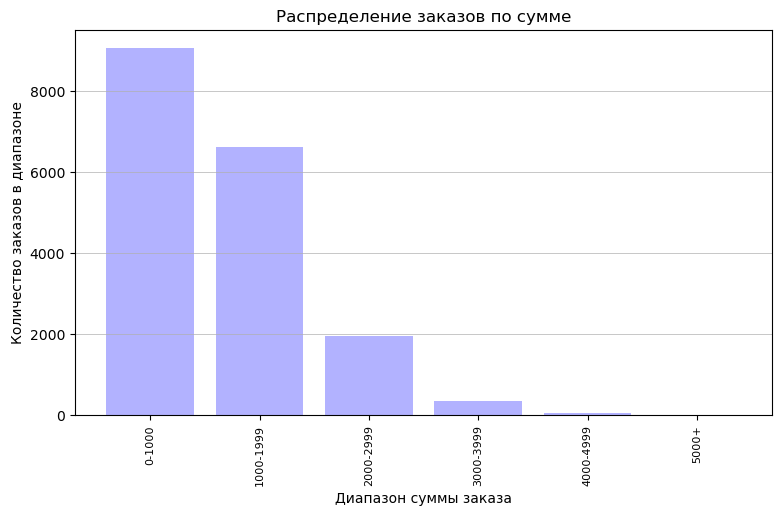

In [105]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 5))
ax.bar(df_ts_group['sum_group'], df_ts_group['cnt_ord'], alpha = .3, color = 'blue')
ax.grid(axis='y', linewidth=0.5)
ax.set_xlabel('Диапазон суммы заказа')
plt.xticks(fontsize = 8, rotation = 90)
ax.set_ylabel('Количество заказов в диапазоне')
ax.set_title('Распределение заказов по сумме')
plt.show()

In [107]:
## Загрузка таблицы №3 - реестр заказов
df_ord = pd.read_csv('orders_20260606.csv')
df_ord.head(3)

,order_id,customer_id,order_date,delivery_date,status,total_amount,delivery_address,promo_code,payment_method
0,1,1448,2024-11-06 20:02:00.000,2024-11-07,delivered,581.81,"Санкт-Петербург, Фрунзенский р-н, ул. Примерна...",WELCOME10,cash
1,2,1930,2024-08-26 18:33:00.000,2024-08-27,delivered,1491.84,"Санкт-Петербург, Центральный р-н, ул. Примерна...",NaN,card
2,3,2326,2024-11-05 14:24:00.000,2024-11-06,delivered,705.85,"Санкт-Петербург, Приморский р-н, ул. Примерная...",FRESH20,card


In [109]:
## Типы данных в столбцах и количество строк
df_ord.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          18000 non-null  int64  
 1   customer_id       18000 non-null  int64  
 2   order_date        18000 non-null  object 
 3   delivery_date     18000 non-null  object 
 4   status            18000 non-null  object 
 5   total_amount      18000 non-null  float64
 6   delivery_address  18000 non-null  object 
 7   promo_code        8984 non-null   object 
 8   payment_method    18000 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 1.2+ MB


In [111]:
## Перевод столбцов с информацией о времени в формат даты и времени
df_ord['order_date'] = pd.to_datetime(df_ord['order_date'], errors = 'coerce')
df_ord['delivery_date'] = pd.to_datetime(df_ord['delivery_date'], errors = 'coerce')

In [113]:
## Характеристики числовых столбцов
df_ord.describe()

,order_id,customer_id,order_date,delivery_date,total_amount
count,18000.000000,18000.000000,18000,18000,18000.000000
mean,9000.500000,1237.868222,2024-06-17 01:38:46.753333504,2024-06-17 11:11:21.600000,1126.874250
min,1.000000,1.000000,2024-01-01 08:08:00,2024-01-02 00:00:00,19.490000
25%,4500.750000,614.000000,2024-03-25 08:11:15,2024-03-26 00:00:00,546.322500
50%,9000.500000,1231.000000,2024-06-17 10:30:00,2024-06-18 00:00:00,993.600000
75%,13500.250000,1854.000000,2024-09-08 16:34:15,2024-09-09 00:00:00,1559.792500
max,18000.000000,2500.000000,2024-12-01 20:48:00,2024-12-02 00:00:00,5503.260000
std,5196.296758,718.232147,NaN,NaN,751.513647


In [115]:
## Группировка заказов (только доставленных) по клиентам
df_cust_mo = df_ord[df_ord['status'] == 'delivered'].groupby(['customer_id'])['order_id'].count().reset_index()\
.rename (columns = {'order_id' : 'cnt_orders'}).sort_values ('cnt_orders', ascending = False)
df_cust_mo.head(5)

,customer_id,cnt_orders
1190,1192,16
3,4,16
1250,1253,16
2034,2037,15
307,309,15


In [119]:
df_summary['max_ord_per_cust'] = df_cust_mo['cnt_orders'].max()
print (df_summary)

   cust_reg  cust_act  share_new      tot_rev  avg_ord_sum  cnt_ord  \
0      2500      2133        0.3  20283734.23      1126.87    18000   

   avg_items_per_ord  max_ord_per_cust  
0                4.6                16  


In [121]:
## Соединение таблиц заказов и клиентов
df_orders_cust = df_ord.merge(df_cust, on = 'customer_id', how = 'left')
df_orders_cust.head(3)

,order_id,customer_id,order_date,delivery_date,status,total_amount,delivery_address,promo_code,payment_method,first_name,last_name,email,phone,registration_date,city,district,is_active,acquisition_channel,reg_y_m
0,1,1448,2024-11-06 20:02:00,2024-11-07,delivered,581.81,"Санкт-Петербург, Фрунзенский р-н, ул. Примерна...",WELCOME10,cash,Наталья,Попова,user1448@freshbox.local,79393152423,2024-07-28,Санкт-Петербург,Фрунзенский,True,organic,2024-07
1,2,1930,2024-08-26 18:33:00,2024-08-27,delivered,1491.84,"Санкт-Петербург, Центральный р-н, ул. Примерна...",NaN,card,Наталья,Сидорова,user1930@freshbox.local,79403435126,2024-02-09,Санкт-Петербург,Центральный,True,organic,2024-02
2,3,2326,2024-11-05 14:24:00,2024-11-06,delivered,705.85,"Санкт-Петербург, Приморский р-н, ул. Примерная...",FRESH20,card,Ирина,Петрова,user2326@freshbox.local,79844316831,2024-04-30,Санкт-Петербург,Приморский,True,organic,2024-04


In [123]:
## Распределение сумм заказов по каналам привлечения клиентов
df_chan_rev = df_orders_cust.groupby('acquisition_channel')['total_amount'].sum().reset_index()
df_chan_rev.sort_values('total_amount', ascending = False)

,acquisition_channel,total_amount
0,organic,8346684.65
3,social,4867019.68
2,referral,3972821.12
1,paid,3097211.05


In [125]:
## Соединение таблицы заказов с таблицей с информацией о содержании заказов
df_orders_merg = df_ord_info.merge(df_ord, on = 'order_id').rename(columns = {'id_user' : 'cnt_act_users'})

In [127]:
## Добавление к объединенной таблице столбца с годом-месяцем заказа
df_orders_merg['ord_y_m'] = df_orders_merg['order_date'].dt.strftime ("%Y-%m")

In [129]:
## Расчет количества заказов, среднего количества позиций в одном заказе, количества покупателей и сумм заказов за каждый месяц
df_orders_merg['cnt_ord'] = df_orders_merg.loc[df_orders_merg['status'] == 'delivered'].groupby('ord_y_m')['order_id']\
.transform('count')
df_orders_merg['avg_items'] = df_orders_merg.loc[df_orders_merg['status'] == 'delivered'].groupby('ord_y_m')['cnt_items']\
.transform('mean')
df_orders_merg['cnt_cust'] = df_orders_merg.loc[df_orders_merg['status'] == 'delivered'].groupby('ord_y_m')['customer_id']\
.transform('nunique')
df_orders_merg['amount_mon'] = df_orders_merg.loc[df_orders_merg['status'] == 'delivered'].groupby('ord_y_m')['total_amount']\
.transform('sum')

In [131]:
## Расчет средней стоимости заказа
df_orders_merg['avg_ord_amt'] = df_orders_merg['amount_mon'] / df_orders_merg['cnt_ord']
df_orders_merg.head(3)

,order_id,cnt_items,total_sum,sum_group,customer_id,order_date,delivery_date,status,total_amount,delivery_address,promo_code,payment_method,ord_y_m,cnt_ord,avg_items,cnt_cust,amount_mon,avg_ord_amt
0,1,4,581.80,0-1000,1448,2024-11-06 20:02:00,2024-11-07,delivered,581.81,"Санкт-Петербург, Фрунзенский р-н, ул. Примерна...",WELCOME10,cash,2024-11,1535.0,4.043648,1142.0,1529727.03,996.564840
1,2,7,1491.83,1000-1999,1930,2024-08-26 18:33:00,2024-08-27,delivered,1491.84,"Санкт-Петербург, Центральный р-н, ул. Примерна...",NaN,card,2024-08,1533.0,5.996086,1159.0,2255893.18,1471.554586
2,3,5,705.85,0-1000,2326,2024-11-05 14:24:00,2024-11-06,delivered,705.85,"Санкт-Петербург, Приморский р-н, ул. Примерная...",FRESH20,card,2024-11,1535.0,4.043648,1142.0,1529727.03,996.564840


In [133]:
## То же самое с помощью группировки
df_ord_dynamic = df_orders_merg.loc[df_orders_merg['status'] == 'delivered'].groupby('ord_y_m').\
agg({'order_id' : 'count', 'cnt_items' : 'mean', 'customer_id' : 'nunique', 'total_amount' : 'sum'})\
.rename(columns = {'order_id' : 'cnt_ord', 'cnt_items' : 'avg_items', 'customer_id' : 'cnt_cust', 'total_amount' : 'amount_mon'}).reset_index()
df_ord_dynamic

,ord_y_m,cnt_ord,avg_items,cnt_cust,amount_mon
0,2024-01,1574,4.036213,1197,1546984.32
1,2024-02,1484,4.002695,1126,1467448.89
2,2024-03,1547,4.027796,1150,1536850.94
3,2024-04,1563,3.994242,1156,1538195.31
4,2024-05,1564,4.000639,1154,1547346.38
5,2024-06,1508,6.130637,1130,2318353.31
6,2024-07,1630,5.928834,1187,2343497.17
7,2024-08,1533,5.996086,1159,2255893.18
8,2024-09,1512,4.033069,1153,1505711.24
9,2024-10,1568,4.005102,1191,1556958.75


In [135]:
df_ord_dynamic['avg_ord_amt'] = df_ord_dynamic['amount_mon'] / df_ord_dynamic['cnt_ord']
df_ord_dynamic

,ord_y_m,cnt_ord,avg_items,cnt_cust,amount_mon,avg_ord_amt
0,2024-01,1574,4.036213,1197,1546984.32,982.836290
1,2024-02,1484,4.002695,1126,1467448.89,988.846961
2,2024-03,1547,4.027796,1150,1536850.94,993.439522
3,2024-04,1563,3.994242,1156,1538195.31,984.130077
4,2024-05,1564,4.000639,1154,1547346.38,989.351905
5,2024-06,1508,6.130637,1130,2318353.31,1537.369569
6,2024-07,1630,5.928834,1187,2343497.17,1437.728325
7,2024-08,1533,5.996086,1159,2255893.18,1471.554586
8,2024-09,1512,4.033069,1153,1505711.24,995.840767
9,2024-10,1568,4.005102,1191,1556958.75,992.958386


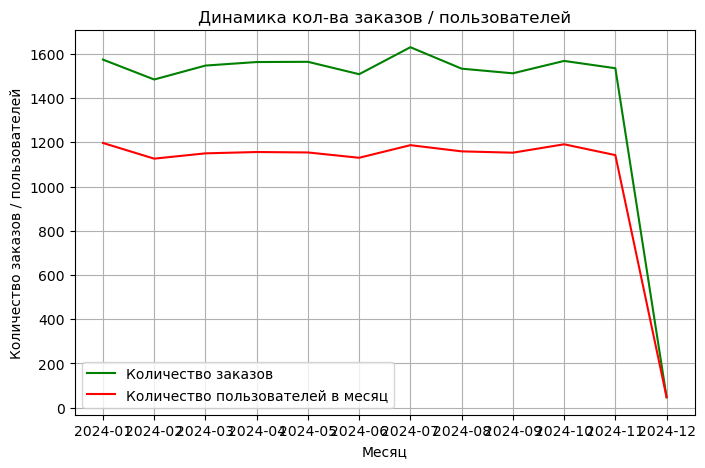

In [137]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
ax.plot(df_ord_dynamic['ord_y_m'], df_ord_dynamic['cnt_ord'], 'g', label = 'Количество заказов')
ax.plot(df_ord_dynamic['ord_y_m'], df_ord_dynamic['cnt_cust'], 'r', label = 'Количество пользователей в месяц')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов / пользователей')
plt.title('Динамика кол-ва заказов / пользователей')
plt.legend()
plt.grid(True)
# plt.savefig('Users_dynamic.png',
#             dpi=300,
#             bbox_inches='tight'
#             )

# plt.close()
plt.show()

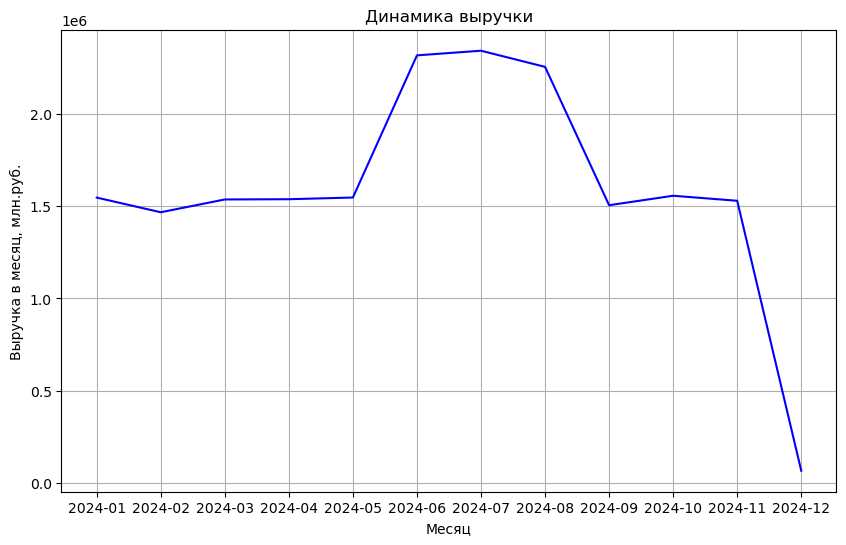

In [139]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.plot(df_ord_dynamic['ord_y_m'], df_ord_dynamic['amount_mon'], 'b', label = 'Выручка за месяц')
plt.xlabel('Месяц')
plt.ylabel('Выручка в месяц, млн.руб.')
plt.title('Динамика выручки')
plt.grid(True)
# plt.savefig('Users_dynamic.png',
#             dpi=300,
#             bbox_inches='tight'
#             )

# plt.close()
plt.show()

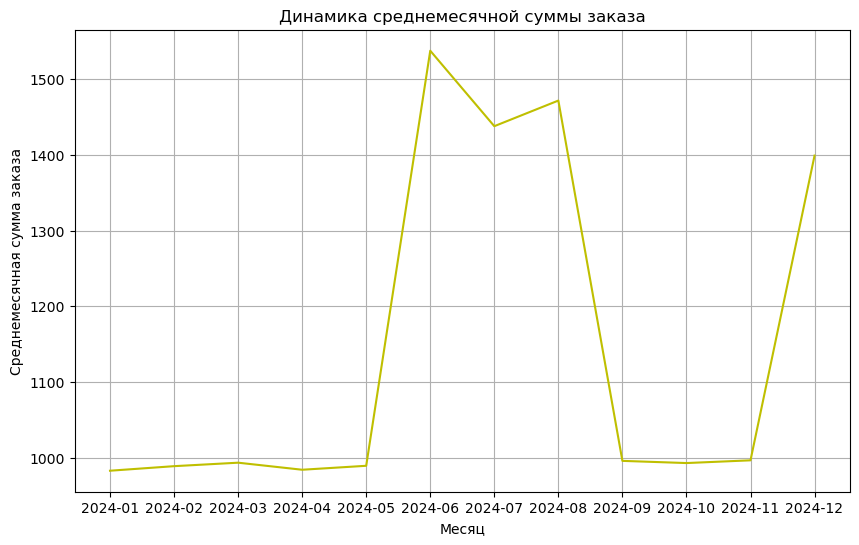

In [141]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.plot(df_ord_dynamic['ord_y_m'], df_ord_dynamic['avg_ord_amt'], 'y', label = 'Среднемесячная сумма заказа')
plt.xlabel('Месяц')
plt.ylabel('Среднемесячная сумма заказа')
plt.title('Динамика среднемесячной суммы заказа')
plt.grid(True)
# plt.savefig('Users_dynamic.png',
#             dpi=300,
#             bbox_inches='tight'
#             )

# plt.close()
plt.show()

In [143]:
## Загрузка таблицы №4 - о товарах
df_pr = pd.read_csv('products_20260606.csv')
df_pr.head(3)

,product_id,name,category,unit,price,cost,supplier,is_available,seasonal_start,seasonal_end
0,1,Огурцы эко,vegetables,kg,69.72,45.20,"""Ферма """"Зелёный Луг""""""",True,NaN,NaN
1,2,Огурцы отборные,vegetables,kg,70.71,51.09,"""Ферма """"Зелёный Луг""""""",True,NaN,NaN
2,3,Огурцы эко,vegetables,kg,69.85,38.08,"""Кооператив """"Свой""""""",True,NaN,NaN


In [145]:
## Типы данных и количество строк в таблице
df_pr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      104 non-null    int64  
 1   name            104 non-null    object 
 2   category        104 non-null    object 
 3   unit            104 non-null    object 
 4   price           104 non-null    float64
 5   cost            104 non-null    float64
 6   supplier        104 non-null    object 
 7   is_available    104 non-null    bool   
 8   seasonal_start  32 non-null     object 
 9   seasonal_end    32 non-null     object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 7.5+ KB


In [147]:
## Дубликатов нет
df_pr.duplicated().any()

np.False_

In [149]:
## Список не доступных для заказа продуктов
df_non_av = df_pr.loc[df_pr['is_available'] == False].copy()
df_non_av

,product_id,name,category,unit,price,cost,supplier,is_available,seasonal_start,seasonal_end
12,13,Лук эко,vegetables,kg,57.91,36.16,"""Агрохолдинг """"Север""""""",False,NaN,NaN
19,20,Перец эко,vegetables,kg,65.45,43.73,Локальные производители,False,NaN,NaN
34,35,Клубника фермерские,fruits,kg,157.90,95.64,"""Кооператив """"Свой""""""",False,NaN,NaN
89,90,Форель эко,seafood,kg,413.69,280.79,"""Кооператив """"Свой""""""",False,NaN,NaN
93,94,Креветки отборные,seafood,kg,673.96,417.61,"""Ферма """"Зелёный Луг""""""",False,2024-06-01,2024-09-30


In [151]:
## Распределение товаров по категориям
df_pr['category'].value_counts()

category
vegetables    20
fruits        18
seafood       18
dairy         17
meat          17
bakery        14
Name: count, dtype: int64

In [153]:
## Распределение товаров по поставщикам
df_supp = df_pr.groupby('supplier')['product_id'].nunique().reset_index().rename(columns = {'product_id' : 'cnt_prod'})
df_supp

,supplier,cnt_prod
0,"""Агрохолдинг """"Север""""""",31
1,"""Кооператив """"Свой""""""",28
2,"""Ферма """"Зелёный Луг""""""",22
3,Локальные производители,23


In [155]:
## В таблице товаров оставили только необходимые для анализа столбцы
df_pr_list = df_pr.drop(['unit', 'price', 'cost', 'is_available', 'seasonal_start', 'seasonal_end'], axis=1)
df_pr_list.head(3)

,product_id,name,category,supplier
0,1,Огурцы эко,vegetables,"""Ферма """"Зелёный Луг"""""""
1,2,Огурцы отборные,vegetables,"""Ферма """"Зелёный Луг"""""""
2,3,Огурцы эко,vegetables,"""Кооператив """"Свой"""""""


In [157]:
## Соединение таблиц заказов и товаров
df_orders_prod = df_oi.merge(df_pr_list, on = 'product_id', how = 'left')
df_orders_prod.head(3)

,item_id,order_id,product_id,quantity,price_at_purchase,discount_percent,total_sum,name,category,supplier
0,1,1,30,0.41,145.27,5,56.58,Бананы свежие,fruits,"""Ферма """"Зелёный Луг"""""""
1,2,1,12,0.53,86.70,0,45.95,Лук свежие,vegetables,"""Кооператив """"Свой"""""""
2,3,1,92,1.08,322.88,5,331.27,Форель свежие,seafood,"""Кооператив """"Свой"""""""


In [180]:
## Группировка выручки по категориям товаров
df_cat_rev = df_orders_prod.groupby('category')['total_sum'].sum().reset_index()
df_cat_rev

,category,total_sum
0,bakery,1135538.76
1,dairy,2266793.68
2,fruits,1883448.19
3,meat,6598003.48
4,seafood,7002697.99
5,vegetables,1397252.13


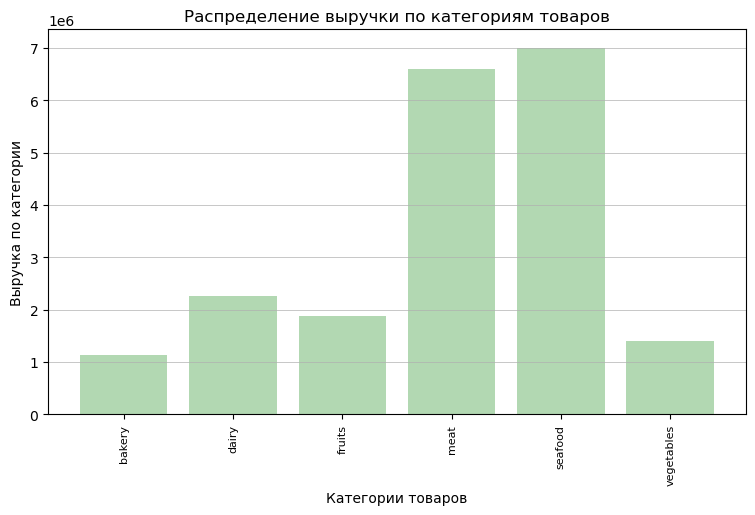

In [178]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 5))
ax.bar(df_cat_rev['category'], df_cat_rev['total_sum'], alpha = .3, color = 'green')
ax.grid(axis='y', linewidth=0.5)
ax.set_xlabel('Категории товаров')
plt.xticks(fontsize = 8, rotation = 90)
ax.set_ylabel('Выручка по категории')
ax.set_title('Распределение выручки по категориям товаров')
plt.show()

In [159]:
## В таблице заказов оставили только необходимые для анализа столбцы
df_ord_list = df_ord[df_ord['status'] == 'delivered'].drop(['delivery_date','delivery_address', 'status', 'promo_code', 'payment_method'], axis=1)
df_ord_list.head(3) 

,order_id,customer_id,order_date,total_amount
0,1,1448,2024-11-06 20:02:00,581.81
1,2,1930,2024-08-26 18:33:00,1491.84
2,3,2326,2024-11-05 14:24:00,705.85


In [161]:
## Объединение таблиц с информацией о заказах
df_orders_prod2 = df_orders_prod.merge(df_ord_list, on = 'order_id', how = 'left')
df_orders_prod2['order_y_m'] = df_orders_prod2['order_date'].dt.to_period('M')
df_orders_prod2.head(3)

,item_id,order_id,product_id,quantity,price_at_purchase,discount_percent,total_sum,name,category,supplier,customer_id,order_date,total_amount,order_y_m
0,1,1,30,0.41,145.27,5,56.58,Бананы свежие,fruits,"""Ферма """"Зелёный Луг""""""",1448.0,2024-11-06 20:02:00,581.81,2024-11
1,2,1,12,0.53,86.70,0,45.95,Лук свежие,vegetables,"""Кооператив """"Свой""""""",1448.0,2024-11-06 20:02:00,581.81,2024-11
2,3,1,92,1.08,322.88,5,331.27,Форель свежие,seafood,"""Кооператив """"Свой""""""",1448.0,2024-11-06 20:02:00,581.81,2024-11


In [163]:
## Группировка выручки по категориям товаров в динамике
df_cat_rev_dyn = df_orders_prod2.groupby(['order_y_m', 'category'])['total_sum'].sum().reset_index()
df_cat_rev_dyn.head(3)

,order_y_m,category,total_sum
0,2024-01,bakery,92574.94
1,2024-01,dairy,179918.59
2,2024-01,fruits,144210.26


In [174]:
with pd.ExcelWriter('eda_report.xlsx') as writer:
    df_summary.to_excel(writer, sheet_name = 'summary', index=False)
    df_cust_pt.to_excel(writer, sheet_name='summary_cust', index=False)
    df_chan_rev.to_excel(writer, sheet_name='summary_ord', index=False)
    df_ord_dynamic.to_excel(writer, sheet_name='summary_dyn', index=False)
    df_cat_rev_dyn.to_excel(writer, sheet_name='categories', index=False)
    df_anomalis.to_excel(writer, sheet_name='anomalies', index=False)